In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
import os
from skimage.segmentation import felzenszwalb

In [2]:
train_path = Path("../EWS-Dataset/train")
validate_path = Path("../EWS-Dataset/validation")
test_path = Path("../EWS-Dataset/test")

In [3]:
def get_imgs(path):
    data = glob.glob(os.path.join(path, "*.png"))
    imgs = [x for x in data if "mask" not in x]
    labels = [x for x in data if "mask" in x]
    return imgs, labels

In [13]:
def get_stats(mask, label):
    tp = np.sum((mask == 0) & (label == 0)).astype(float)
    fp = np.sum((mask == 0) & (label == 255)).astype(float)
    fn = np.sum((mask == 255) & (label == 0)).astype(float)
    tn = np.sum((mask == 255) & (label == 255)).astype(float)
    acc = (tp + tn) / (tp + fp + fn + tn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    if (tp + fp) == 0:
        precision = 0
    return acc, recall, precision

In [5]:
trn_imgs, trn_labels = get_imgs(train_path)
vld_imgs, vld_labels = get_imgs(validate_path)
tst_imgs, tst_labels = get_imgs(test_path)

vld_imgs = trn_imgs + vld_imgs
vld_labels = trn_labels + vld_labels

In [ ]:
# img = cv2.imread(vld_imgs[1])

# Validiation testing
scale = [20, 50, 100, 150]
sigma = [0, 0.1, 0.5, 1.0]
min_size = [1, 3, 10]
stats = np.zeros((len(scale), len(sigma), len(min_size), 3))

for i in range(len(scale)):
    for j in range(len(sigma)):
        for k in range(len(min_size)):
            print(k)
            stat_holder = np.zeros((len(vld_imgs), 3))
            for count in range(len(vld_imgs)):
                print(count)
                img = cv2.imread(vld_imgs[count])
                segments = felzenszwalb(img, scale=scale[i], sigma=sigma[j], min_size=min_size[k])
                h, w = np.shape(segments)

                # Filter segments into background and foreground.
                mask = np.zeros_like(segments)
                regions = np.zeros((len(np.unique(segments)), 3))
                for x in range(len(regions)):
                    regions[x, :] = np.mean(img[segments == x], axis = 0)
                g_r_diff = regions[:, 1] - regions[:, 2]
                segment_labels = np.arange(0, len(np.unique(segments)), 1)
                positive_green = (g_r_diff) < 0
                lookup = np.zeros(len(segment_labels))
                lookup[segment_labels] = positive_green
                mask = 255 * lookup[segments]

                label = cv2.imread(vld_labels[count], cv2.IMREAD_GRAYSCALE)
                _, label = cv2.threshold(label, 127, 255, cv2.THRESH_BINARY)
                acc, recall, precision = get_stats(mask, label)
                stat_holder[count, :] = (acc, recall, precision)
        
            stats[i, j, k, :] = (np.mean(stat_holder[:,0]), np.mean(stat_holder[:,1]), np.mean(stat_holder[:,2]))



# # Felzenszwalb returns regions of different labels
# segments = felzenszwalb(img, scale=3.0, sigma=0.95, min_size=5)

# h, w = np.shape(segments)
# # Filter segments into background and foreground.
# mask = np.zeros_like(segments)
# regions = np.zeros((len(np.unique(segments)), 3))
# for i in range(len(regions)):
#     regions[i, :] = np.mean(img[segments == i], axis = 0)

In [19]:
stats[0, 0, 1]

array([0.87141677, 0.7891727 , 0.64857579])

In [21]:
images = []
labels = []
masks = []
tst_stats = np.zeros((len(tst_imgs), 3))
for i in range(len(tst_imgs)):
    img = cv2.imread(tst_imgs[i])
    segments = felzenszwalb(img, scale=scale[0], sigma=sigma[0], min_size=min_size[1])
    h, w = np.shape(segments)

    # Filter segments into background and foreground.
    mask = np.zeros_like(segments)
    regions = np.zeros((len(np.unique(segments)), 3))
    for x in range(len(regions)):
        regions[x, :] = np.mean(img[segments == x], axis = 0)
    g_r_diff = regions[:, 1] - regions[:, 2]
    segment_labels = np.arange(0, len(np.unique(segments)), 1)
    positive_green = (g_r_diff) < 0
    lookup = np.zeros(len(segment_labels))
    lookup[segment_labels] = positive_green
    mask = 255 * lookup[segments]

    label = cv2.imread(tst_labels[i], cv2.IMREAD_GRAYSCALE)
    _, label = cv2.threshold(label, 127, 255, cv2.THRESH_BINARY)
    acc, recall, precision = get_stats(mask, label)
    tst_stats[i, :] = (acc, recall, precision)

    images.append(img)
    labels.append(label)
    masks.append(mask)
    
total_acc = np.mean(tst_stats[:,0])
total_recall = np.mean(tst_stats[:,1])
total_precision = np.mean(tst_stats[:,2])

In [25]:
print(f"Average test accuracy: {total_acc}")
print(f"Average test recall: {total_recall}")
print(f"Average test precision: {total_precision}")

Average test accuracy: 0.8213108843537414
Average test recall: 0.8427477558778916
Average test precision: 0.6328595299398904


In [176]:
process = []
pro_tst_stats = np.zeros((len(tst_imgs), 3))
for i in range(len(tst_imgs)):
    processed = post_process(masks[i])
    process.append(processed)
    acc, recall, precision = get_stats(processed, labels[i])
    pro_tst_stats[i, :] = (acc, recall, precision)

pro_total_acc = np.mean(pro_tst_stats[:,0])
pro_total_recall = np.mean(pro_tst_stats[:,1])
pro_total_precision = np.mean(pro_tst_stats[:,2])
    

In [177]:
print(f"Average post-processed test accuracy: {pro_total_acc}")
print(f"Average post-processed test recall: {pro_total_recall}")
print(f"Average post-processed test precision: {pro_total_precision}")

Average post-processed test accuracy: 0.833893537414966
Average post-processed test recall: 0.8141268784781491
Average post-processed test precision: 0.6865880599882322


In [178]:
# g_r_diff = regions[:, 1] - regions[:, 2]
# segment_labels = np.arange(0, len(np.unique(segments)), 1)
# positive_green = (g_r_diff) < 0
# lookup = np.zeros(len(segment_labels))
# lookup[segment_labels] = positive_green


# mask = 255 * lookup[segments]

In [179]:
def post_process(mask):
    mask_int = cv2.bitwise_not(mask.astype(np.uint8))
    # kernel = np.ones((5,5), np.uint8)
    # process = cv2.morphologyEx(process, cv2.MORPH_CLOSE, kernel, iterations=2)
    # process = cv2.morphologyEx(mask,cv2.MORPH_OPEN,kernel,iterations = 1)

    # Find contours
    contours, _ = cv2.findContours(mask_int, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Remove small dots
    areas = [cv2.contourArea(x) for x in contours]
    contoursSmall = []

    for i, x in enumerate(contours):
        if areas[i] < 50:
            contoursSmall.append(x)
    cv2.drawContours(mask_int, contoursSmall, -1, 0, thickness = cv2.FILLED)

    
    mask_int = cv2.bitwise_not(mask_int)
    return mask_int

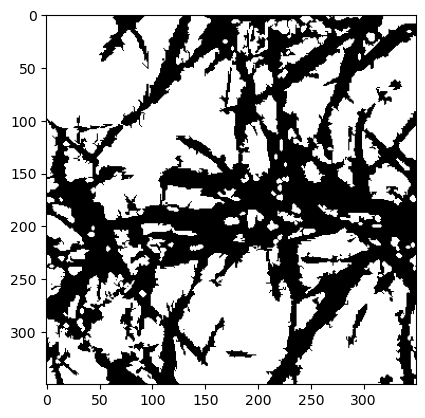

In [180]:
plt.imshow(process[3], cmap = "gray")

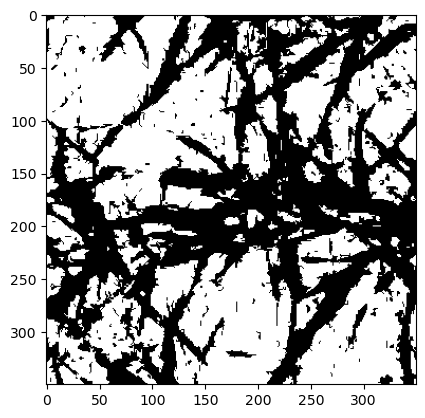

In [181]:
plt.imshow(masks[3], cmap = "gray")

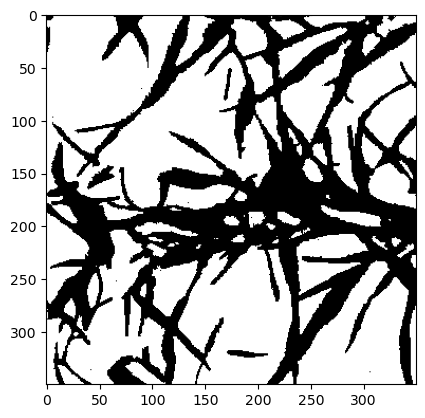

In [182]:
plt.imshow(labels[3], cmap = "gray")